# 04 - Modeling

Scale RFM features, run k-selection diagnostics (Elbow + Silhouette),
train the final K-Means model, profile and label clusters, and visualize
the results with PCA. This is the notebook where `k` is chosen -- a
judgment call informed by the diagnostic plots below, not a fully
automated decision.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())

from src.data.load_data import load_config, load_raw_data
from src.data.preprocess import clean_transactions
from src.features.feature_engineering import assign_segments, compute_rfm, score_rfm
from src.models.train import (
    compute_elbow_inertia,
    compute_silhouette_scores,
    fit_kmeans,
    label_clusters_by_value,
    profile_clusters,
    save_model_artifacts,
    scale_rfm_features,
)
from src.visualization.plots import plot_clusters_pca, plot_elbow, plot_silhouette

config = load_config("config.yaml")
raw = load_raw_data(config)
clean = clean_transactions(raw)
rfm = compute_rfm(clean, config["rfm"]["reference_date_offset_days"])
rfm = score_rfm(rfm, config["rfm"]["n_bins"])
rfm = assign_segments(rfm)

scaled, scaler = scale_rfm_features(rfm)
scaled.shape

(4338, 3)

## Choosing k

Inertia (Elbow method) and Silhouette scores across a range of `k`
values. Look for where inertia's rate of decrease levels off, and where
silhouette score is highest -- ideally both point to a similar `k`.

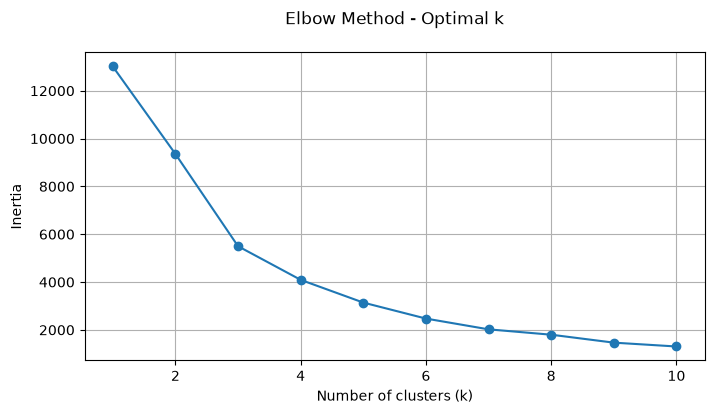

In [2]:
inertia = compute_elbow_inertia(scaled, random_state=config["model"]["random_state"])
_ = plot_elbow(inertia, config["reports"]["figures_dir"])

{2: 0.5603671809121974, 3: 0.5852924318247733, 4: 0.616212846765192, 5: 0.617115186725246, 6: 0.5982715957283189, 7: 0.51717221452567, 8: 0.49091567183009177, 9: 0.484017028247486, 10: 0.42503454870703994}


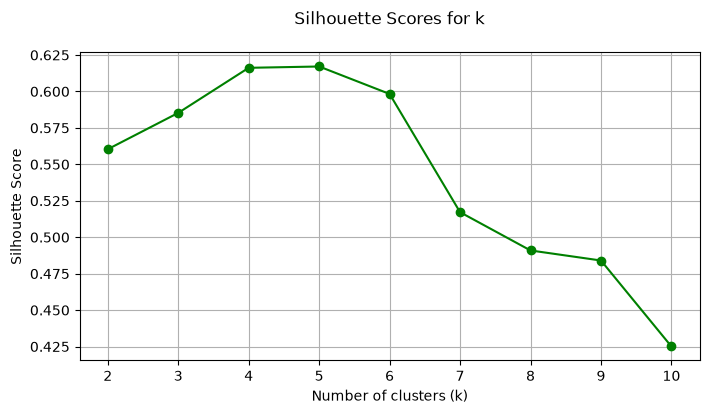

In [3]:
silhouette = compute_silhouette_scores(scaled, random_state=config["model"]["random_state"])
_ = plot_silhouette(silhouette, config["reports"]["figures_dir"])
print(silhouette)

As explored during development: silhouette scores for k=4 and k=5 are
nearly tied (~0.616 vs ~0.617), with k=3 noticeably lower. `k=4`
(configured in `config.yaml`) is kept as it's well-justified by these
diagnostics and consistent with the original analysis.

In [4]:
kmeans = fit_kmeans(
    scaled,
    n_clusters=config["model"]["n_clusters"],
    random_state=config["model"]["random_state"],
)
rfm["Cluster"] = kmeans.predict(scaled)

cluster_summary = profile_clusters(rfm)
cluster_summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,43.7,3.7,1359.0,3054
1,248.1,1.6,480.6,1067
2,7.4,82.5,127338.3,13
3,15.5,22.3,12709.1,204


## Labeling Clusters

Clusters are labeled by ranking mean Monetary value (descending), not
by hardcoded cluster index -- KMeans assigns cluster indices arbitrarily,
so this keeps labeling correct regardless of index order.

In [5]:
cluster_labels = label_clusters_by_value(cluster_summary)
rfm["Cluster_Label"] = rfm["Cluster"].map(cluster_labels)
cluster_labels

{2: 'VIP', 3: 'Loyal High-Spender', 0: 'Mid-Value', 1: 'At Risk'}

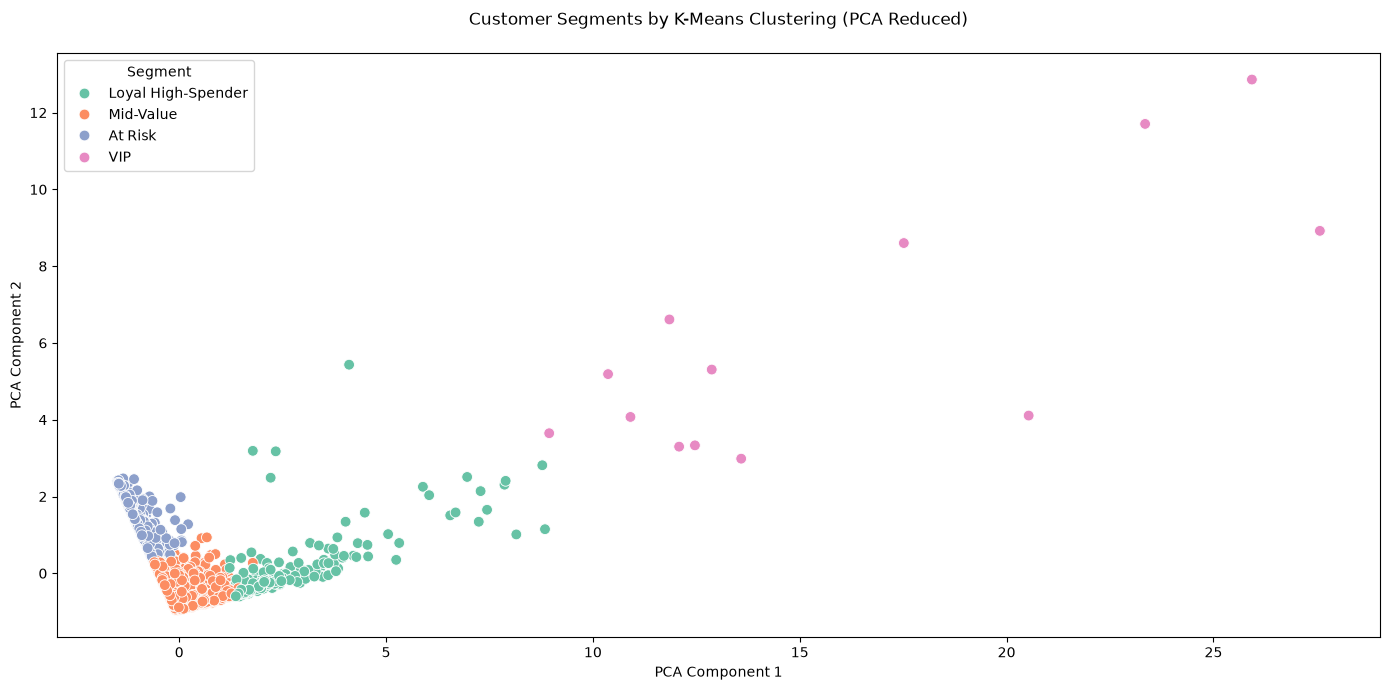

In [6]:
_ = plot_clusters_pca(scaled, rfm["Cluster_Label"], config["reports"]["figures_dir"])

## Save Model Artifacts

Persist the fitted model, scaler, and cluster label mapping so new
customer data can be scored later without retraining
(see `src/models/predict.py`).

In [7]:
save_model_artifacts(kmeans, scaler, cluster_labels, config["models"]["dir"])
print("Model artifacts saved to", config["models"]["dir"])

Model artifacts saved to models
